## 1. Import Necessary Packages

In [63]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
import torchaudio
import numpy as np
import kaggle
import matplotlib.pyplot as plt
import pandas as pd
import librosa
from pathlib import Path
from mutagen.mp3 import MP3
from mutagen import MutagenError
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from collections import Counter
from typing import Literal

## 2. Define Default Values

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")
dataFolder = './data'
dataPath = Path(dataFolder)

Using: cuda


## 3. Download Data
In this, I will be using the [FMA Medium dataset](https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium).
Ensure that you have set your kaggle api token as an environment variable (KAGGLE_API_TOKEN) amd have enough storage for this dataset (34.26 GB).
I made this automatically check if the `./data` folder exists and skips the download if it does to prevent repeated downloadeds, to avoid this, just delete the `./data` folder when you need to redownload.

In [19]:
if not dataPath.exists():
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('imsparsh/fma-free-music-archive-small-medium', path=dataFolder, unzip=True)

## 4. Clean and Prepare Data
Get genre names and create Dataset class to read the files. Rather than loading all 34GB into memory, this will pull the files at read time.

### Load Metadata

In [ ]:
def load_fma_dataset(data_folder: str, subset: Literal['small', 'medium'] = 'medium'):
    """
    Loads FMA dataset from files to in-memory based on the subsets.

        Args:
            data_folder (string): The location that the FMA data is in
            subset ('small' | 'medium'): The dataset to be loaded

        Returns: 
            pd.DataFrame with the following columns:
                track_id - file name without the .mp3
                filepath - absolute path to the file
                genre_id - corresponding genre id from genres.csv
                split - testing, training, or validation split
                label - the output label for the genre_id
                genre_title - the full name for the genre, i.e. Electronic
    """
    genres_df = pd.read_csv(f'{data_folder}/fma_metadata/genres.csv', index_col=0)
    print(genres_df.describe)
    
    tracks_df = pd.read_csv(f'{data_folder}/fma_metadata/tracks.csv', index_col=0, header=[0, 1])

    # The FMA dataset has predetermined test/train/val splits and sizes
    subset_mask = tracks_df['set', 'subset'] == subset
    tracks_df = tracks_df[subset_mask]

    rows = []
    for track_id, row in tracks_df.iterrows():
        # file naming: folder name (3 digits) + track id (3 digits) -> unique file name (6 digits)
        id_str = str(track_id).zfill(6)
        folder = id_str[:3]
        filename = id_str + '.mp3'
        filepath = Path(data_folder) / f"fma_{subset}" / f"fma_{subset}" / folder / filename

        if not filepath.exists():
            continue
            
        genre_id = row['track', 'genre_top']
        split: Literal['training', 'validation', 'test'] = row['set', 'split']
        rows.append({
            'track_id': id_str,
            'filepath': str(filepath.resolve()),
            'genre_id': genre_id,
            'split': split
        })

    df = pd.DataFrame(rows)

    # Map genre_id to integer label [0, N)
    unique_genres = sorted(df['genre_id'].dropna().unique())
    genre_to_idx = {g: i for i, g in enumerate(unique_genres)}
    df['label'] = df['genre_id'].map(genre_to_idx)

    df['genre_title'] = df['genre_id'].map(genres_df['title'])

    return df, genre_to_idx

df, genre_map = load_fma_dataset(dataFolder)

print("Genres:")
for g, i in genre_map.items():
    print(f'{i+1}. {g}, label={i}')

<bound method NDFrame.describe of           #tracks  parent          title  top_level
genre_id                                           
1            8693      38    Avant-Garde         38
2            5271       0  International          2
3            1752       0          Blues          3
4            4126       0           Jazz          4
5            4106       0      Classical          5
...           ...     ...            ...        ...
1032           60     102        Turkish          2
1060           30      46          Tango          2
1156           26     130           Fado          2
1193           72     763      Christmas         38
1235        14938       0   Instrumental       1235

[163 rows x 4 columns]>
Genres:
1. Blues, label=0
2. Classical, label=1
3. Country, label=2
4. Easy Listening, label=3
5. Electronic, label=4
6. Experimental, label=5
7. Folk, label=6
8. Hip-Hop, label=7
9. Instrumental, label=8
10. International, label=9
11. Jazz, label=10
12. Old-Time /

### Create Custom Dataset

In [68]:
class CustomDataset(Dataset):
    def __init__(
            self, 
            df: pd.DataFrame,
            log_mels: bool,
            cqt: bool,
            sample_rate: int = 22050, 
            duration: float = 30.0, 
            n_mels: int = 128,
            n_bins: int = 84,
            bins_per_octave: int = 12,
            n_fft: int = 2048,
            hop_length: int = 512,
            cache_dir: str = None,
            transform: transforms = None,
            num_workers: int = 4
        ):
        # dataset
        self.video_labels = df['label'].to_numpy()
        self.video_paths = df['filepath'].to_numpy()
        
        self.transform = transform
        self.num_workers = num_workers

        # spectrogram values
        self.log_mels = log_mels
        self.cqt = cqt
        if not cqt and not log_mels:
            raise ValueError("log_mels or cqt must be true.")
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_mels = n_mels
        self.n_bins = n_bins
        self.bins_per_octave = bins_per_octave
        self.n_fft = n_fft
        self.hop_length = hop_length

        # cache
        self.cache_dir = Path(cache_dir) if cache_dir else None
        if self.cache_dir:
            self.cache_dir.mkdir(parents=True, exist_ok=True)

        # stats
        self.lm_mean = 0.0
        self.lm_std = 0.0
        self.cqt_mean = 0.0
        self.cqt_std = 0.0

    def cache_idx(self, idx: int) -> bool:
        try:
            self.__getitem__(idx)
            return True
        except:
            return False

    def precache_all(self) -> list[str]:
        if not self.cache_dir:
            return []

        N = len(self.video_labels)
        success = [False] * N
        with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
            futures = {
                executor.submit(self.cache_idx, i):i for i in range(N)
            }
            for future in tqdm(as_completed(futures), total=len(futures), desc="Caching"):
                i = futures[future]
                success[i] = future.result()
        self.video_labels = [self.video_labels[i] for i in range(N) if success[i]]
        self.video_paths = [self.video_paths[i] for i in range(N) if success[i]]
        return [i for i in range(N) if not success[i]]

    def mp3_to_log_mel(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.sample_rate * self.duration)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sample_rate,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Normalize to [0,1]
        log_mel = (log_mel-log_mel.min())/(log_mel.max()-log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)

    def mp3_to_cqt(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.duration * self.sample_rate)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        cqt = librosa.cqt(
            y=audio,
            sr=self.sample_rate,
            n_bins = self.n_bins,
            bins_per_octave = self.bins_per_octave,
            hop_length=self.hop_length,
            fmin=librosa.note_to_hz('C1')
        )

        # Normalize to [0,1]
        log_cqt = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
        log_cqt = (log_cqt-log_cqt.min())/(log_cqt.max()-log_cqt.min()+1e-8)
        return log_cqt.astype(np.float32)
        

    def load_and_compute_lm(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_lm_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        lm_spec = self.mp3_to_log_mel(path)

        if self.cache_dir:
            np.save(cache_path, lm_spec)

        return lm_spec
    
    def load_and_compute_cqt(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_cqt_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        cqt_val = self.mp3_to_cqt(path)

        if self.cache_dir:
            np.save(cache_path, cqt_val)
        
        return cqt_val

    def __len__(self) -> int:
        return len(self.video_labels)
    
    def __getitem__(self, idx: int) -> np.ndarray:
        label = self.video_labels[idx]
        vid = self.video_paths[idx]
        
        if self.log_mels and self.cqt:
            lm_spect = self.load_and_compute_lm(vid)
            cqt_spect = self.load_and_compute_cqt(vid)

            # Get mean and std (use if dataset updated)
            self.lm_mean += lm_spect.reshape(-1).mean()
            self.lm_std += lm_spect.reshape(-1).std()
            self.cqt_mean += cqt_spect.reshape(-1).mean()
            self.cqt_std += cqt_spect.reshape(-1).mean()

            cqt_spect_padded = np.pad(cqt_spect, ((0, self.n_mels - self.n_bins), (0, 0)))

            # Stack lm and cqt
            stacked_output = np.stack([lm_spect, cqt_spect_padded], axis=0)
            stacked_output = torch.tensor(stacked_output, dtype=torch.float32)
            
            if self.transform:
                stacked_output = self.transform(stacked_output)
            return stacked_output, label
        elif self.log_mels:
            lm_spect = self.load_and_compute_lm(vid)
            lm_spect = torch.tensor(lm_spect, dtype=torch.float32).unsqueeze(0)

            if self.transform:
                lm_spect = self.transform(lm_spect)
            return lm_spect, label
        else:
            cqt_spect = self.load_and_compute_cqt(vid)
            cqt_spect = torch.tensor(cqt_spect, dtype=torch.float32).unsqueeze(0)

            if self.transform:
                cqt_spect = self.transform(cqt_spect)
            return cqt_spect, label

### Load Dataset

In [94]:
# Calculated mean and std values [lm_val, cqt_val]
transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.35981735587120056, 0.3470417857170105],
        std=[0.09834757447242737, 0.3563712537288666]
    ),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=30),   # mask up to 30 frequency bins
    torchaudio.transforms.TimeMasking(time_mask_param=100),        # mask up to 100 time frames
    torchaudio.transforms.TimeMasking(time_mask_param=100),        # apply twice for stronger effect

    transforms.RandomErasing(p=0.3),
])
cache = './cache'

train_df = df[df['split'] == 'training'].reset_index(drop=True)
val_df = df[df['split'] == 'validation'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

train_ds = CustomDataset(train_df, True, True, cache_dir=cache, transform=transform)
val_ds = CustomDataset(val_df, True, True, cache_dir=cache, transform=transform)
test_ds = CustomDataset(test_df, True, True, cache_dir=cache, transform=transform)

# Precaching will help to validate that all the .mp3 files are accessible.
train_ds.precache_all()
val_ds.precache_all()
test_ds.precache_all()

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Caching:   1%|          | 141/13522 [00:00<01:03, 210.13it/s]C:\Users\Dylan Lederman\AppData\Local\Temp\ipykernel_7912\1191221283.py:74: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
d:\anaconda3\envs\ai-genre\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Caching: 100%|██████████| 1773/1773 [00:08<00:00, 214.18it/s]


In [95]:
# Gets mean and std, not needed when already computed
print(len(train_ds))
mean = (np.array([train_ds.lm_mean, train_ds.cqt_mean]) / len(train_ds.video_paths)).tolist()
std = (np.array([train_ds.lm_std, train_ds.cqt_std]) / len(train_ds.video_paths)).tolist()
print(f"mean: {mean}, std: {std}")

13509
mean: [0.4381946623325348, 0.4872068166732788], std: [0.14915786683559418, 0.49124282598495483]


### View dataset
*Do not run if using multiple workers in DataLoader

Label: 13 — Shape: torch.Size([2, 128, 1292])


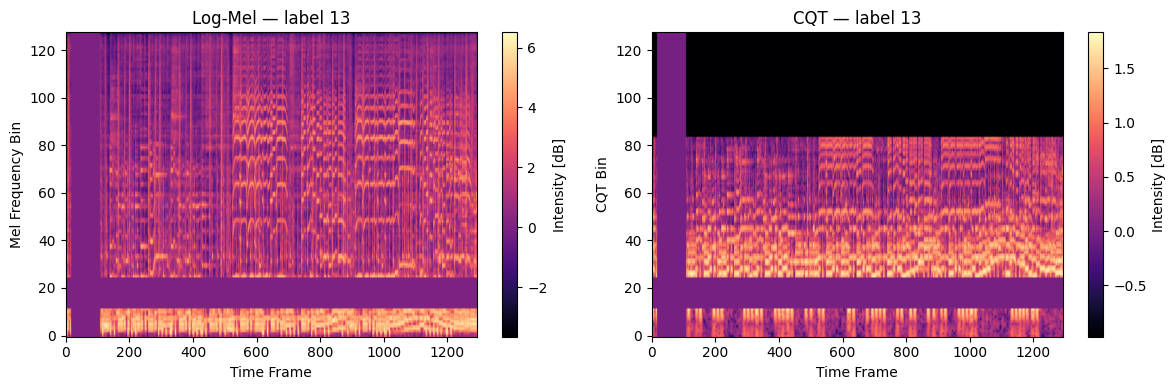

Label: 13 — Shape: torch.Size([2, 128, 1292])


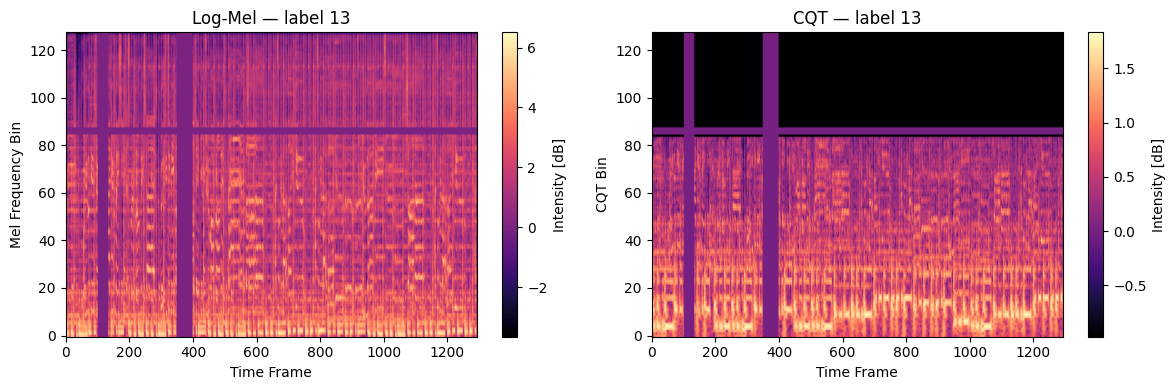

In [98]:
# These will be transformed (normalized)
def visualize_dataset(loader, ds):
    data = next(iter(loader))
    inputs, labels = data
    N = 2

    for i in range(N):
        input = inputs[i]   # (C, 128, T) where C is 1 or 2
        label = labels[i].item()
        print(f"Label: {label} — Shape: {input.shape}")

        n_channels = input.shape[0]
        fig, axes = plt.subplots(1, n_channels, figsize=(6 * n_channels, 4))

        # Ensure axes is always iterable even if n_channels == 1
        if n_channels == 1:
            axes = [axes]

        titles = []
        if ds.log_mels:
            titles.append(('Log-Mel', 'Mel Frequency Bin'))
        if ds.cqt:
            titles.append(('CQT', 'CQT Bin'))

        for ax, channel, (title, ylabel) in zip(axes, range(n_channels), titles):
            im = ax.imshow(input[channel], origin='lower', aspect='auto', cmap='magma')
            ax.set_ylabel(ylabel)
            ax.set_xlabel('Time Frame')
            ax.set_title(f'{title} — label {label}')
            fig.colorbar(im, ax=ax, label='Intensity [dB]')

        plt.tight_layout()
        plt.show()

visualize_dataset(train_loader, train_ds)

## 5. Create the Network

### Model

In [113]:
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

# Replace first conv — pretrained weights expect 3 channels
model.conv1 = torch.nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(p=0.5),
    torch.nn.Linear(model.fc.in_features, len(genre_map))
)

## 6. Train the Network

### Testing and Accuracy Functions

In [106]:
def check_accuracy(loader, model) -> float:
    print("Checking Accuracy")
    model = model.to(device=device)
    num_correct = num_samples = 0
    model.eval()
    with torch.no_grad():
        for input, label in loader:
            x = input.to(device=device)
            y = label.to(device=device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(f"Got {num_correct} / {num_samples} with accuracy {float(num_correct)/float(num_samples)*100:.2f}")
    return float(num_correct)/float(num_samples)

def train_model(train_loader, valid_loader, model, optimizer, scheduler, loss_fn, epochs) -> tuple[list[float], list[float], list[float]]:
    model = model.to(device=device)
    train_accuracy = []
    losses = []
    validation_acc = []
    for e in range(epochs):
        epoch_loss = 0.0
        num_right = 0
        num_total = 0
        for input, label in tqdm(train_loader, total=len(train_loader), desc="Batch"):
            model.train()
            x = input.to(device=device)
            y = label.to(device=device)

            score = model(x)
            loss = loss_fn(score, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            

            actual = torch.argmax(score, dim=1)
            
            num_right += sum([1 if actual[i] == y[i] else 0 for i in range(len(y))])
            num_total += y.size(0)

            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)

        print(f"Epoch {e+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {num_right}/{num_total}")
        val_acc = check_accuracy(valid_loader, model)
        print()
        scheduler.step(val_acc)
        validation_acc.append(val_acc)
        losses.append(avg_loss)
        train_accuracy.append(float(num_right)/float(num_total))
    return train_accuracy, losses, validation_acc

### Training
Implemented 2 phase training due to constantt validation accuracy. This hopefully allows the new head to learn before adjusting the ResNet-18 body.

In [114]:
# Set device
model = model.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
epochs_head = 3
epochs = 10

# Phase 1 - train head, freeze body
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

model.conv1.weight.requires_grad = True

# Define functions and values to be used for training
optimizer_head = torch.optim.Adam([
    {
        'params': model.conv1.parameters(), 'lr': 1e-4
    },
    {
        'params': model.fc.parameters(), 'lr': 1e-4
    },
], weight_decay=1e-3)

scheduler_head = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_head,
    T_max=epochs_head,
    eta_min=1e-6
)

train_accuracy_head, losses_head, validation_acc_head = train_model(train_loader, val_loader, model, optimizer_head, scheduler_head, loss_fn, epochs_head)

# Phase 2 - train full network, set body to low lr
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {'params': model.conv1.parameters(), 'lr': 1e-4},
    {'params': model.layer1.parameters(), 'lr': 1e-5},
    {'params': model.layer2.parameters(), 'lr': 1e-5},
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4},
], weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=1e-6
)
torch.cuda.empty_cache()
# Train the model
train_accuracy, losses, validation_acc = train_model(train_loader, val_loader, model, optimizer, scheduler, loss_fn, epochs,)

Batch: 100%|██████████| 423/423 [03:17<00:00,  2.14it/s]


Epoch 1/3, Loss: 1.8234, Accuracy: 5724/13509
Checking Accuracy


C:\Users\Dylan Lederman\AppData\Local\Temp\ipykernel_7912\3071935188.py:52: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_acc)


Got 939 / 1704 with accuracy 55.11



Batch: 100%|██████████| 423/423 [03:19<00:00,  2.12it/s]


...

Epoch 8/10, Loss: 0.8295, Accuracy: 10142/13509
Checking Accuracy
Got 1281 / 1704 with accuracy 75.18



Batch: 100%|██████████| 423/423 [02:51<00:00,  2.47it/s]


Epoch 9/10, Loss: 0.8092, Accuracy: 10136/13509
Checking Accuracy
Got 1273 / 1704 with accuracy 74.71



Batch: 100%|██████████| 423/423 [02:56<00:00,  2.40it/s]


Epoch 10/10, Loss: 0.7903, Accuracy: 10218/13509
Checking Accuracy
Got 1264 / 1704 with accuracy 74.18



### Visualize Training Results

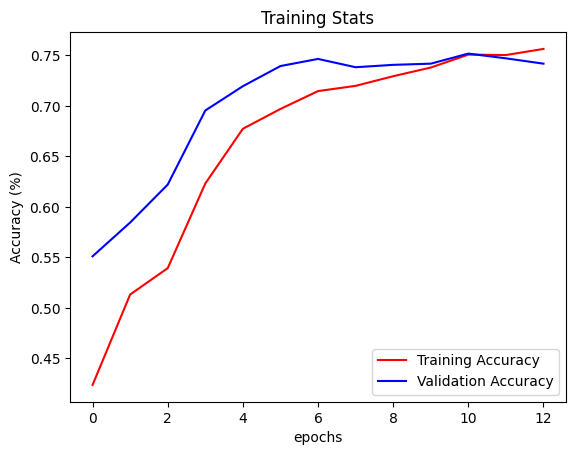

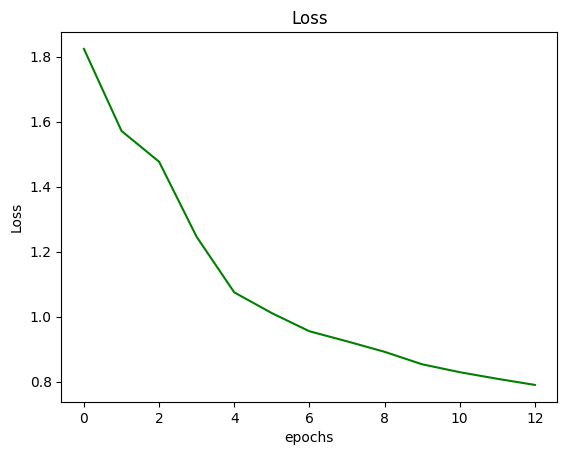

In [115]:
train_accuracy, losses, validation_acc
plt.plot(train_accuracy_head + train_accuracy, label="Training Accuracy", color='red')
plt.plot(validation_acc_head + validation_acc, label="Validation Accuracy", color='blue')
plt.title("Training Stats")
plt.xlabel("epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()
plt.plot(losses_head + losses, label="Training Loss", color='green')
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.show()

## 7. Test the Network

In [116]:
train_acc = check_accuracy(test_loader, model)
print(f"Testing accuracy: {train_acc:.2f}")

Checking Accuracy
Got 1288 / 1772 with accuracy 72.69
Testing accuracy: 0.73
